In [1]:
# ==========================================
# PART 1 — Load & Preprocess MNIST
# ==========================================

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# Convert images to PyTorch Tensors
transform = transforms.ToTensor()


# Load Training Set
train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


# Load Test Set
test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


# Create DataLoaders
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)


print("Training samples:", len(train_data))
print("Test samples:", len(test_data))
print("Image shape:", train_data[0][0].shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 337kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.80MB/s]

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


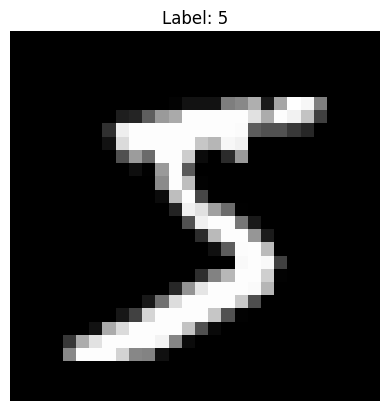

Tensor shape: torch.Size([1, 28, 28])
Minimum value: 0.0
Maximum value: 1.0


In [2]:
# ==========================================
# PART 2 — Explore the Data
# ==========================================

import matplotlib.pyplot as plt

# Take one image and its label
image, label = train_data[0]

# Display the image
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

# Print tensor information
print("Tensor shape:", image.shape)
print("Minimum value:", image.min().item())
print("Maximum value:", image.max().item())

In [3]:
# ==========================================
# PART 3 — Flatten the Image
# ==========================================

# Take one batch from the DataLoader
images, labels = next(iter(train_loader))

print("Before Flatten:", images.shape)

# Flatten each image
images_flat = images.view(images.size(0), -1)

print("After Flatten:", images_flat.shape)

Before Flatten: torch.Size([64, 1, 28, 28])
After Flatten: torch.Size([64, 784])


In [4]:
# ==========================================
# PART 4 — Build the MLP
# ==========================================

class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


# Create the model
model = MLP()

print(model)

MLP(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [5]:
# ==========================================
# PART 5 — Forward Pass
# ==========================================

# Take one batch
images, labels = next(iter(train_loader))

# Flatten images
images = images.view(images.size(0), -1)

# Pass the images through the model
outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([64, 784])
Output shape: torch.Size([64, 10])


In [6]:
# ==========================================
# PART 6 — Loss Function
# ==========================================

# Define the loss function
loss_function = nn.CrossEntropyLoss()

# Calculate loss for the current predictions
loss = loss_function(outputs, labels)

print("Loss:", loss.item())

Loss: 2.3080379962921143


In [9]:
# ==========================================
# PART 7 — Optimizer
# ==========================================

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

print("Optimizer:", optimizer)

# ==========================================
# PART 8 — Backpropagation
# ==========================================

optimizer.zero_grad()

loss.backward()

print("Gradients calculated.")

Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
Gradients calculated.


In [10]:
# ==========================================
# PART 9 — Training Step
# ==========================================

# Take one batch
images, labels = next(iter(train_loader))

# Flatten images
images = images.view(images.size(0), -1)

# Clear previous gradients
optimizer.zero_grad()

# Forward Pass
outputs = model(images)

# Calculate Loss
loss = loss_function(outputs, labels)

# Backpropagation
loss.backward()

# Update Weights
optimizer.step()

print("Training step completed.")
print("Loss:", loss.item())

Training step completed.
Loss: 2.312323570251465


In [11]:
# ==========================================
# PART 10 — Training Loop
# ==========================================

num_epochs = 10

for epoch in range(num_epochs):

    total_loss = 0

    for images, labels in train_loader:

        # Flatten images
        images = images.view(images.size(0), -1)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward Pass
        outputs = model(images)

        # Calculate Loss
        loss = loss_function(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update Weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/10, Loss: 1.2551
Epoch 2/10, Loss: 0.4992
Epoch 3/10, Loss: 0.3958
Epoch 4/10, Loss: 0.3536
Epoch 5/10, Loss: 0.3283
Epoch 6/10, Loss: 0.3101
Epoch 7/10, Loss: 0.2953
Epoch 8/10, Loss: 0.2827
Epoch 9/10, Loss: 0.2712
Epoch 10/10, Loss: 0.2607


In [12]:
# ==========================================
# PART 11 — Evaluate on Test Set
# ==========================================

correct = 0
total = 0

# We are evaluating, not training
with torch.no_grad():

    for images, labels in test_loader:

        # Flatten images
        images = images.view(images.size(0), -1)

        # Get model predictions
        outputs = model(images)

        # Choose the class with the highest score
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


accuracy = correct / total

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9303


In [13]:
# ==========================================
# PART 12 — Single Image Prediction
# ==========================================

# Take one image from the test set
image, label = test_data[0]

# Flatten the image
x = image.view(1, -1)

# Pass the image through the model
output = model(x)

# Get the predicted digit
_, predicted = torch.max(output, 1)

print("True label:", label)
print("Predicted digit:", predicted.item())

True label: 7
Predicted digit: 7


In [14]:
# ==========================================
# PART 13 — Softmax & Probabilities
# ==========================================

probabilities = F.softmax(output, dim=1)

for digit, probability in enumerate(probabilities[0]):

    print(
        f"Digit {digit}: "
        f"{probability.item():.4f}"
    )

print(
    "Sum:",
    probabilities.sum().item()
)

Digit 0: 0.0001
Digit 1: 0.0000
Digit 2: 0.0003
Digit 3: 0.0022
Digit 4: 0.0000
Digit 5: 0.0001
Digit 6: 0.0000
Digit 7: 0.9963
Digit 8: 0.0000
Digit 9: 0.0012
Sum: 0.9999999403953552


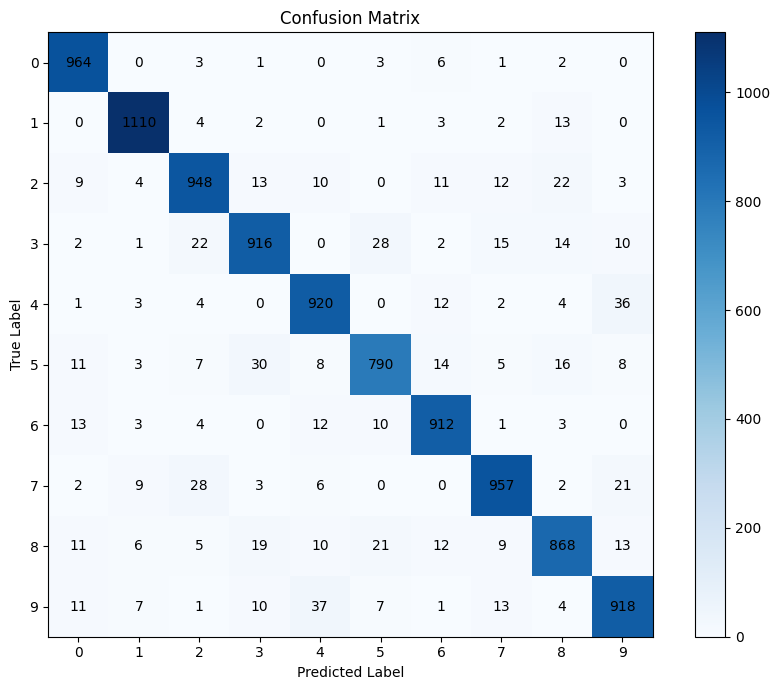

In [15]:
# ==========================================
# PART 14 — Confusion Matrix
# ==========================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.view(
            images.size(0), -1
        )

        outputs = model(images)

        _, predicted = torch.max(
            outputs, 1
        )

        all_predictions.extend(
            predicted.tolist()
        )

        all_labels.extend(
            labels.tolist()
        )


# Create confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)


# Visualize
plt.figure(figsize=(9, 7))

plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(range(10))
plt.yticks(range(10))

# Add numbers to cells
for i in range(10):
    for j in range(10):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [16]:
# ==========================================
# PART 15 — Error Analysis
# ==========================================

errors = cm.copy()

# Remove correct predictions
for i in range(10):
    errors[i, i] = 0

top_errors = []

for _ in range(5):

    true_label, predicted_label = divmod(
        errors.argmax(),
        10
    )

    count = errors[
        true_label,
        predicted_label
    ]

    top_errors.append(
        (
            true_label,
            predicted_label,
            count
        )
    )

    errors[
        true_label,
        predicted_label
    ] = 0


print("Top 5 Misclassifications:")

for true_label, predicted_label, count in top_errors:

    print(
        f"True {true_label} → "
        f"Predicted {predicted_label}: "
        f"{count} times"
    )

Top 5 Misclassifications:
True 9 → Predicted 4: 37 times
True 4 → Predicted 9: 36 times
True 5 → Predicted 3: 30 times
True 3 → Predicted 5: 28 times
True 7 → Predicted 2: 28 times


Most common error: 9 → 4


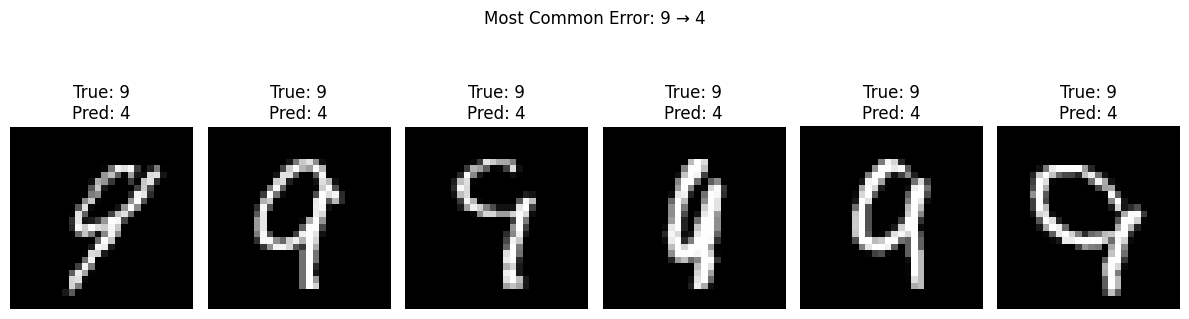

In [18]:
# ==========================================
# PART 16 — Visualize Most Common Error
# ==========================================

# Find the most common misclassification
errors = cm.copy()

for i in range(10):
    errors[i, i] = 0

true_label, predicted_label = divmod(
    errors.argmax(),
    10
)

print(
    f"Most common error: "
    f"{true_label} → {predicted_label}"
)


# Find images with this error
wrong_images = []

with torch.no_grad():

    for images, labels in test_loader:

        images_flat = images.view(
            images.size(0), -1
        )

        outputs = model(images_flat)

        _, predicted = torch.max(
            outputs, 1
        )

        for i in range(len(labels)):

            if (
                labels[i].item() == true_label
                and predicted[i].item() == predicted_label
            ):

                wrong_images.append(
                    (
                        images[i],
                        labels[i],
                        predicted[i]
                    )
                )


# Display first 6 examples
plt.figure(figsize=(12, 4))

for i in range(min(6, len(wrong_images))):

    image, true_label, predicted_label = wrong_images[i]

    plt.subplot(1, 6, i + 1)

    plt.imshow(
        image.squeeze(),
        cmap="gray"
    )

    plt.title(
        f"True: {true_label.item()}\n"
        f"Pred: {predicted_label.item()}"
    )

    plt.axis("off")

plt.suptitle(
    f"Most Common Error: "
    f"{true_label} → {predicted_label}"
)

plt.tight_layout()
plt.show()

In [ ]:
----------------------------------------------------------------------------------------------------------

In [103]:
# ==========================================
# PART 17 — Interactive Digit Drawing
# ==========================================

from IPython.display import display, HTML
from google.colab import output
import base64

from PIL import Image
import io
import numpy as np

import torch
import torch.nn.functional as F


# ==========================================
# Store Last Processed Image
# ==========================================

last_custom_image = None


# ==========================================
# HTML + Canvas
# ==========================================

html = """
<div id="drawingApp">

<canvas id="canvas"
        width="280"
        height="280"
        style="
            border:2px solid black;
            background:white;
            cursor:crosshair;
        ">
</canvas>

<br><br>

<button id="clearBtn">Clear</button>
<button id="predictBtn">Predict</button>

<pre id="result"
     style="
        margin-top:15px;
        font-family:monospace;
        white-space:pre-line;
     ">
</pre>

<script>

const canvas = document.getElementById("canvas");
const ctx = canvas.getContext("2d");

const result = document.getElementById("result");


function resetCanvas() {

    ctx.fillStyle = "white";
    ctx.fillRect(0, 0, 280, 280);

    ctx.strokeStyle = "black";
    ctx.lineWidth = 20;
    ctx.lineCap = "round";
    ctx.lineJoin = "round";

    result.textContent = "";
}

resetCanvas();


let drawing = false;


canvas.addEventListener("mousedown", function(e) {

    drawing = true;

    const rect = canvas.getBoundingClientRect();

    ctx.beginPath();

    ctx.moveTo(
        e.clientX - rect.left,
        e.clientY - rect.top
    );
});


canvas.addEventListener("mousemove", function(e) {

    if (!drawing) return;

    const rect = canvas.getBoundingClientRect();

    ctx.lineTo(
        e.clientX - rect.left,
        e.clientY - rect.top
    );

    ctx.stroke();
});


canvas.addEventListener("mouseup", function() {

    drawing = false;
    ctx.beginPath();

});


canvas.addEventListener("mouseleave", function() {

    drawing = false;
    ctx.beginPath();

});


document.getElementById("clearBtn").onclick = function() {

    resetCanvas();

};


document.getElementById("predictBtn").onclick = function() {

    const image = canvas.toDataURL("image/png");

    google.colab.kernel.invokeFunction(
        "notebook.predict_digit",
        [image],
        {}
    );

};

</script>

</div>
"""

display(HTML(html))


# ==========================================
# Prediction Function
# ==========================================

def predict_digit(data):

    global last_custom_image

    # Remove Base64 header
    data = data.split(",")[1]

    # Decode image
    image = Image.open(
        io.BytesIO(
            base64.b64decode(data)
        )
    ).convert("L")


    # ==========================================
    # Convert to MNIST Style
    # ==========================================

    # Black drawing → white digit
    image = Image.eval(
        image,
        lambda x: 255 - x
    )


    # ==========================================
    # Crop Digit
    # ==========================================

    bbox = image.getbbox()

    if bbox is not None:

        image = image.crop(bbox)


    # ==========================================
    # Resize Digit
    # ==========================================

    image.thumbnail((20, 20))


    # ==========================================
    # Create 28×28 Canvas
    # ==========================================

    canvas_28 = Image.new(
        "L",
        (28, 28),
        0
    )


    # ==========================================
    # Center Digit
    # ==========================================

    x = (28 - image.width) // 2
    y = (28 - image.height) // 2

    canvas_28.paste(
        image,
        (x, y)
    )

    image = canvas_28


    # ==========================================
    # Save Processed Image
    # ==========================================

    last_custom_image = (
        np.array(
            image,
            dtype=np.float32
        ) / 255.0
    )


    # ==========================================
    # Convert to Tensor
    # ==========================================

    custom_tensor = torch.tensor(
        last_custom_image,
        dtype=torch.float32
    )


    # ==========================================
    # Flatten
    # ==========================================

    custom_input = custom_tensor.view(
        1, -1
    )


    # ==========================================
    # Prediction
    # ==========================================

    model.eval()

    with torch.no_grad():

        custom_output = model(
            custom_input
        )


    _, prediction = torch.max(
        custom_output,
        1
    )


    # ==========================================
    # Probabilities
    # ==========================================

    probabilities = F.softmax(
        custom_output,
        dim=1
    )


    # ==========================================
    # Create Result
    # ==========================================

    result_text = (
        f"Predicted digit: "
        f"{prediction.item()}\n\n"
    )


    for digit, probability in enumerate(
        probabilities[0]
    ):

        result_text += (
            f"Digit {digit}: "
            f"{probability.item():.4f}\n"
        )


    # ==========================================
    # Display Current Result
    # ==========================================

    display(
        HTML(
            f"""
            <script>

            document.getElementById(
                "result"
            ).textContent = `{result_text}`;

            </script>
            """
        )
    )


# ==========================================
# Register Callback
# ==========================================

output.register_callback(
    "notebook.predict_digit",
    predict_digit
)

=========================================================================================


In [96]:
# ==========================================
# PART 18 — Build CNN
# ==========================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ==========================================
# CNN Model
# ==========================================

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        # First convolution
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        # Second convolution
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Fully connected layers
        self.fc1 = nn.Linear(
            32 * 7 * 7,
            128
        )

        self.fc2 = nn.Linear(
            128,
            10
        )


    def forward(self, x):

        # Convolution + ReLU
        x = F.relu(
            self.conv1(x)
        )

        # Downsample
        x = F.max_pool2d(
            x,
            2
        )

        # Second convolution
        x = F.relu(
            self.conv2(x)
        )

        # Downsample
        x = F.max_pool2d(
            x,
            2
        )

        # Flatten
        x = x.view(
            x.size(0),
            -1
        )

        # Fully connected
        x = F.relu(
            self.fc1(x)
        )

        # Output
        x = self.fc2(x)

        return x


# ==========================================
# Create CNN
# ==========================================

cnn_model = CNN()

print(cnn_model)

CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [97]:
# ==========================================
# PART 19 — CNN Forward Pass
# ==========================================

# Take one batch from MNIST
images, labels = next(iter(train_loader))

print("Input shape:", images.shape)

# Forward pass
outputs = cnn_model(images)

print("Output shape:", outputs.shape)

Input shape: torch.Size([64, 1, 28, 28])
Output shape: torch.Size([64, 10])


In [98]:
# ==========================================
# PART 20 — CNN Loss & Optimizer
# ==========================================

# Loss function
cnn_loss_function = nn.CrossEntropyLoss()

# Optimizer
cnn_optimizer = torch.optim.SGD(
    cnn_model.parameters(),
    lr=0.01
)

print("Loss function:", cnn_loss_function)
print("Optimizer:", cnn_optimizer)

Loss function: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


In [99]:
# ==========================================
# PART 21 — CNN Training
# ==========================================

num_epochs = 10

for epoch in range(num_epochs):

    total_loss = 0

    for images, labels in train_loader:

        # Clear gradients
        cnn_optimizer.zero_grad()

        # Forward pass
        outputs = cnn_model(images)

        # Calculate loss
        loss = cnn_loss_function(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        cnn_optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss / len(train_loader)
    )

    print(
        f"Epoch {epoch + 1}/{num_epochs}, "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/10, Loss: 1.5741
Epoch 2/10, Loss: 0.3497
Epoch 3/10, Loss: 0.2399
Epoch 4/10, Loss: 0.1769
Epoch 5/10, Loss: 0.1373
Epoch 6/10, Loss: 0.1142
Epoch 7/10, Loss: 0.0981
Epoch 8/10, Loss: 0.0871
Epoch 9/10, Loss: 0.0785
Epoch 10/10, Loss: 0.0717


In [100]:
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: False


In [101]:
# ==========================================
# PART 22 — CNN Test Accuracy
# ==========================================

cnn_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = cnn_model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


cnn_accuracy = correct / total

print(
    f"CNN Test Accuracy: "
    f"{cnn_accuracy:.4f}"
)

CNN Test Accuracy: 0.9798


In [102]:
# ==========================================
# PART 23 — CNN Interactive Prediction
# ==========================================

from IPython.display import display, HTML
from google.colab import output

import base64
from PIL import Image
import io
import numpy as np

import torch
import torch.nn.functional as F


html = """
<div id="cnnDrawingApp">

<canvas id="cnnCanvas"
        width="280"
        height="280"
        style="
            border:2px solid black;
            background:white;
            cursor:crosshair;
        ">
</canvas>

<br><br>

<button id="cnnClearBtn">Clear</button>
<button id="cnnPredictBtn">Predict</button>

<pre id="cnnResult"
     style="
        margin-top:15px;
        font-family:monospace;
        white-space:pre-line;
     ">
</pre>

<script>

const canvas = document.getElementById("cnnCanvas");
const ctx = canvas.getContext("2d");

const result = document.getElementById("cnnResult");


function resetCanvas() {

    ctx.fillStyle = "white";
    ctx.fillRect(0, 0, 280, 280);

    ctx.strokeStyle = "black";
    ctx.lineWidth = 20;
    ctx.lineCap = "round";
    ctx.lineJoin = "round";

    result.textContent = "";
}

resetCanvas();


let drawing = false;


canvas.addEventListener("mousedown", function(e) {

    drawing = true;

    const rect = canvas.getBoundingClientRect();

    ctx.beginPath();

    ctx.moveTo(
        e.clientX - rect.left,
        e.clientY - rect.top
    );
});


canvas.addEventListener("mousemove", function(e) {

    if (!drawing) return;

    const rect = canvas.getBoundingClientRect();

    ctx.lineTo(
        e.clientX - rect.left,
        e.clientY - rect.top
    );

    ctx.stroke();
});


canvas.addEventListener("mouseup", function() {

    drawing = false;
    ctx.beginPath();

});


canvas.addEventListener("mouseleave", function() {

    drawing = false;
    ctx.beginPath();

});


document.getElementById("cnnClearBtn").onclick = function() {

    resetCanvas();

};


document.getElementById("cnnPredictBtn").onclick = function() {

    const image = canvas.toDataURL("image/png");

    google.colab.kernel.invokeFunction(
        "notebook.cnn_predict_digit",
        [image],
        {}
    );

};

</script>

</div>
"""

display(HTML(html))


# ==========================================
# Preprocessing
# ==========================================

def preprocess_cnn_image(data):

    data = data.split(",")[1]

    image = Image.open(
        io.BytesIO(
            base64.b64decode(data)
        )
    ).convert("L")


    # Black drawing → white digit
    image = Image.eval(
        image,
        lambda x: 255 - x
    )


    image_array = np.array(
        image,
        dtype=np.uint8
    )


    # Find digit
    coords = np.argwhere(
        image_array > 20
    )

    if len(coords) == 0:
        return None


    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)


    # Crop
    cropped = image.crop(
        (
            x_min,
            y_min,
            x_max + 1,
            y_max + 1
        )
    )


    # Resize while keeping ratio
    width, height = cropped.size

    scale = 20 / max(
        width,
        height
    )

    new_width = max(
        1,
        int(width * scale)
    )

    new_height = max(
        1,
        int(height * scale)
    )


    cropped = cropped.resize(
        (
            new_width,
            new_height
        ),
        Image.Resampling.LANCZOS
    )


    # Create MNIST-style 28×28 image
    mnist_image = Image.new(
        "L",
        (28, 28),
        0
    )


    # Center
    x_offset = (
        28 - new_width
    ) // 2

    y_offset = (
        28 - new_height
    ) // 2


    mnist_image.paste(
        cropped,
        (
            x_offset,
            y_offset
        )
    )


    # Tensor
    tensor = torch.tensor(
        np.array(
            mnist_image,
            dtype=np.float32
        ) / 255.0
    )

    return tensor


# ==========================================
# CNN Prediction
# ==========================================

def cnn_predict_digit(data):

    custom_tensor = preprocess_cnn_image(data)

    if custom_tensor is None:

        print("Please draw a digit.")

        return


    # CNN expects:
    # [batch, channel, height, width]

    custom_input = custom_tensor.unsqueeze(
        0
    ).unsqueeze(
        0
    )


    cnn_model.eval()

    with torch.no_grad():

        output = cnn_model(
            custom_input
        )


    # Prediction
    prediction = torch.argmax(
        output,
        dim=1
    )


    # Probabilities
    probabilities = F.softmax(
        output,
        dim=1
    )


    result_text = (
        f"Predicted digit: "
        f"{prediction.item()}\n\n"
    )


    for digit, probability in enumerate(
        probabilities[0]
    ):

        result_text += (
            f"Digit {digit}: "
            f"{probability.item():.4f}\n"
        )


    display(
        HTML(
            f"""
            <script>

            document.getElementById(
                "cnnResult"
            ).textContent =
            `{result_text}`;

            </script>
            """
        )
    )


# ==========================================
# Register Callback
# ==========================================

output.register_callback(
    "notebook.cnn_predict_digit",
    cnn_predict_digit
)